# Notebook 12 — Predictive Uncertainty with MC Dropout

## Goal
Estimate how confident the **final system** (ensemble: localization 0.7 + sex_age 0.3)
is in each prediction, so that the most uncertain cases can be **referred to a
dermatologist** instead of being auto-diagnosed (uncertainty-based rejection).

## Method — Monte Carlo Dropout (Gal & Ghahramani, 2016)
Dropout is normally disabled at inference. With MC Dropout we keep it **enabled**
and run **T = 30** stochastic forward passes per patient. Agreement across passes →
confident; disagreement → uncertain. This approximates the Bayesian predictive
distribution without retraining.

## Uncertainty metrics (standard in this field)
- **Predictive entropy** — total uncertainty.
- **Mutual information / BALD** — epistemic uncertainty (the model's own "I don't know").
- **Std of the predicted-class probability** — most intuitive read.
- **Risk–coverage curve** — accuracy / melanoma-recall as a function of rejection rate.

## Scope note
MC Dropout is applied to the **fusion head** (the dropout layers in the metadata
branch and the fusion classifier). The EfficientNet backbone has no active dropout,
so image features are deterministic — this is verified in Part 0.

In [18]:
import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

sys.path.append('../src')
from config import (
    MODELS_DIR, METRICS_DIR, FIGURES_DIR, SPLITS_DIR,
    CLASSES, NUM_CLASSES, CLASS_TO_IDX, IDX_TO_CLASS, CLASS_NAMES_FULL
)
from model import MultimodalModel
from dataset import load_test_multimodal
from transforms import get_val_transforms

import random
random.seed(42); np.random.seed(42); torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# ── Constants ─────────────────────────────────────────────────────────────────
FOLD = 0
MODEL_LOC_PATH = os.path.join(MODELS_DIR, f'multimodal_b0_none_localization_fold{FOLD}.pth')
MODEL_SA_PATH  = os.path.join(MODELS_DIR, f'multimodal_b0_none_sex_age_fold{FOLD}.pth')

METADATA_COLS_LOC = ['localization']
METADATA_COLS_SA  = ['sex', 'age']
PREPROCESSING = 'none'
AGE_MEAN = 51.9

MEL_IDX = CLASS_TO_IDX['mel']

# Final system ensemble weights (selected on validation in nb09)
W_LOC, W_SA = 0.6, 0.4

# MC Dropout passes
T_MC = 30

print(f'MEL_IDX={MEL_IDX} | ensemble {W_LOC}/{W_SA} | T={T_MC}')

Device: cuda
MEL_IDX=4 | ensemble 0.6/0.4 | T=30


In [19]:
# ── Load test datasets (same as nb11) ─────────────────────────────────────────
val_transform = get_val_transforms()
test_dataset_loc = load_test_multimodal(
    preprocessing_mode=PREPROCESSING, metadata_cols=METADATA_COLS_LOC,
    val_transform=val_transform, age_mean=AGE_MEAN)
test_dataset_sa = load_test_multimodal(
    preprocessing_mode=PREPROCESSING, metadata_cols=METADATA_COLS_SA,
    val_transform=val_transform, age_mean=AGE_MEAN)

metadata_dim_loc = test_dataset_loc.get_metadata_dim()   # 15
metadata_dim_sa  = test_dataset_sa.get_metadata_dim()    # 4

# ── Load models ───────────────────────────────────────────────────────────────
model_loc = MultimodalModel(metadata_dim=metadata_dim_loc, efficientnet_version='b0', pretrained=False)
model_loc.load_state_dict(torch.load(MODEL_LOC_PATH, map_location=device))
model_loc = model_loc.to(device).eval()

model_sa = MultimodalModel(metadata_dim=metadata_dim_sa, efficientnet_version='b0', pretrained=False)
model_sa.load_state_dict(torch.load(MODEL_SA_PATH, map_location=device))
model_sa = model_sa.to(device).eval()

print(f'Models loaded. Test samples: {len(test_dataset_loc)}')

Models loaded. Test samples: 1497


/tmp/ipykernel_69820/147123838.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_loc.load_state_dict(torch.load(MODEL_LOC_PATH, map_location=device))
/tmp/ipykernel

In [20]:
# ── Extract all test data (images, metadata, labels) ──────────────────────────
def extract_test_data(dataset):
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)
    imgs, metas, labs = [], [], []
    with torch.no_grad():
        for images, metadata, labels in loader:
            imgs.append(images.numpy()); metas.append(metadata.numpy()); labs.append(labels.numpy())
    return np.concatenate(imgs), np.concatenate(metas), np.concatenate(labs)

images_loc, metadata_loc, labels = extract_test_data(test_dataset_loc)
images_sa,  metadata_sa,  labels_sa = extract_test_data(test_dataset_sa)
assert np.array_equal(labels, labels_sa), 'labels mismatch'

print(f'images_loc: {images_loc.shape} | metadata_loc: {metadata_loc.shape} | '
      f'metadata_sa: {metadata_sa.shape} | labels: {labels.shape}')

images_loc: (1497, 3, 224, 224) | metadata_loc: (1497, 15) | metadata_sa: (1497, 4) | labels: (1497,)


In [21]:
# ── Where is the dropout? (decides the MC inference strategy) ──────────────────
def inspect_stochastic_layers(model, name):
    print(f'== {name} ==')
    found = []
    for n, m in model.named_modules():
        cls = m.__class__.__name__
        if 'Drop' in cls:   # Dropout, DropPath, StochasticDepth, ...
            p = getattr(m, 'p', getattr(m, 'drop_prob', None))
            found.append((n, cls, p))
    in_backbone = [f for f in found if f[0].startswith('backbone')]
    in_head     = [f for f in found if not f[0].startswith('backbone')]
    print(f'  Stochastic layers in BACKBONE: {len(in_backbone)}')
    for n, cls, p in in_backbone:
        print(f'     {n:45s} {cls:16s} p={p}')
    print(f'  Stochastic layers in HEAD (metadata_branch + classifier): {len(in_head)}')
    for n, cls, p in in_head:
        print(f'     {n:45s} {cls:16s} p={p}')
    print()

inspect_stochastic_layers(model_loc, 'model_loc')
inspect_stochastic_layers(model_sa,  'model_sa')

== model_loc ==
  Stochastic layers in BACKBONE: 0
  Stochastic layers in HEAD (metadata_branch + classifier): 3
     metadata_branch.net.2                         Dropout          p=0.3
     classifier.0                                  Dropout          p=0.3
     classifier.3                                  Dropout          p=0.3

== model_sa ==
  Stochastic layers in BACKBONE: 0
  Stochastic layers in HEAD (metadata_branch + classifier): 3
     metadata_branch.net.2                         Dropout          p=0.3
     classifier.0                                  Dropout          p=0.3
     classifier.3                                  Dropout          p=0.3



---
## Part 1 — MC Dropout inference

Since the backbone has no active dropout, image features are deterministic and
computed **once**. The T=30 stochastic passes only run through the fusion head
(metadata branch + classifier), where the dropout lives. For each pass we enable
dropout but keep BatchNorm in eval mode, then combine both models into the final
ensemble (0.7·loc + 0.3·sa). Result: `mc_probs` of shape (T, N, 7).

In [22]:
# ── Precompute deterministic image features (backbone has no dropout) ─────────
def get_image_features(model, images_array, device, batch_size=64):
    feats = []
    model.eval()
    with torch.no_grad():
        for s in range(0, len(images_array), batch_size):
            batch = torch.tensor(images_array[s:s+batch_size]).to(device)
            feats.append(model.backbone(batch).cpu().numpy())
    return np.concatenate(feats, axis=0)

print('Extracting image features...')
img_features_loc = get_image_features(model_loc, images_loc, device)  # (1497, 1280)
img_features_sa  = get_image_features(model_sa,  images_sa,  device)  # (1497, 1280)
print(f'img_features_loc: {img_features_loc.shape} | img_features_sa: {img_features_sa.shape}')

Extracting image features...
img_features_loc: (1497, 1280) | img_features_sa: (1497, 1280)


In [23]:
# ── Enable ONLY dropout layers (keep BatchNorm in eval) ───────────────────────
def enable_mc_dropout(model):
    """Set the model to eval, then re-enable just the Dropout layers."""
    model.eval()
    n = 0
    for m in model.modules():
        if m.__class__.__name__.startswith('Dropout'):
            m.train()
            n += 1
    return n

n1 = enable_mc_dropout(model_loc)
n2 = enable_mc_dropout(model_sa)
print(f'Dropout layers set to train mode — loc: {n1}, sa: {n2} (BatchNorm stays eval)')


def head_forward(model, img_feat_t, meta_t):
    """One stochastic forward through the fusion head (dropout active)."""
    meta_feat = model.metadata_branch(meta_t)          # stochastic
    fused     = torch.cat([img_feat_t, meta_feat], dim=1)
    logits    = model.classifier(fused)                # stochastic
    return torch.softmax(logits, dim=1)

Dropout layers set to train mode — loc: 3, sa: 3 (BatchNorm stays eval)


In [24]:
# ── MC Dropout: T stochastic passes through the head, then ensemble ───────────
def mc_dropout_passes(model, img_features, metadata, device, T, batch_size=512):
    """Returns probs of shape (T, N, 7) for one model."""
    N = len(img_features)
    img_t  = torch.tensor(img_features, dtype=torch.float32, device=device)
    meta_t = torch.tensor(metadata,     dtype=torch.float32, device=device)
    out = np.zeros((T, N, NUM_CLASSES), dtype=np.float32)
    for t in range(T):
        probs_t = []
        with torch.no_grad():
            for s in range(0, N, batch_size):
                p = head_forward(model, img_t[s:s+batch_size], meta_t[s:s+batch_size])
                probs_t.append(p.cpu().numpy())
        out[t] = np.concatenate(probs_t, axis=0)
    return out

torch.manual_seed(42)
print(f'Running {T_MC} MC passes for model_loc...')
mc_loc = mc_dropout_passes(model_loc, img_features_loc, metadata_loc, device, T_MC)  # (T, N, 7)
print(f'Running {T_MC} MC passes for model_sa...')
mc_sa  = mc_dropout_passes(model_sa,  img_features_sa,  metadata_sa,  device, T_MC)  # (T, N, 7)

# Final-system ensemble per pass
mc_probs = W_LOC * mc_loc + W_SA * mc_sa          # (T, N, 7)
print(f'mc_probs: {mc_probs.shape}  (T={T_MC}, N={mc_probs.shape[1]}, classes={NUM_CLASSES})')

# Sanity: mean prediction vs a deterministic-style check
mean_probs = mc_probs.mean(axis=0)                # (N, 7)
print(f'mean_probs sums ≈ 1? {np.allclose(mean_probs.sum(axis=1), 1, atol=1e-4)}')
print(f'Example per-pass std for sample 0, predicted class: '
      f'{mc_probs[:, 0, mean_probs[0].argmax()].std():.4f}')

Running 30 MC passes for model_loc...
Running 30 MC passes for model_sa...
mc_probs: (30, 1497, 7)  (T=30, N=1497, classes=7)
mean_probs sums ≈ 1? True
Example per-pass std for sample 0, predicted class: 0.0498


## Part 2 — Uncertainty metrics

From the T stochastic passes we compute, per patient:

- **Predicted class** = argmax of the mean probability (the system's final prediction).
- **Confidence** = mean probability of the predicted class.
- **Predictive entropy** H[ȳ] — *total* uncertainty (entropy of the mean prediction).
- **Expected entropy** E[H] — average entropy across passes (*aleatoric* component).
- **Mutual information / BALD** = H[ȳ] − E[H] — *epistemic* uncertainty (the model's own
  disagreement across passes).
- **Predicted-class std** — std of the predicted class probability across passes (intuitive).

In [25]:
# ── Uncertainty metrics from mc_probs (T, N, 7) ───────────────────────────────
EPS = 1e-12

mean_probs = mc_probs.mean(axis=0)                         # (N, 7) — final prediction
pred       = mean_probs.argmax(axis=1)                     # (N,)
confidence = mean_probs.max(axis=1)                        # (N,)

# Predictive entropy H[mean] — total uncertainty
predictive_entropy = -np.sum(mean_probs * np.log(mean_probs + EPS), axis=1)   # (N,)

# Expected entropy E_t[H] — aleatoric component
entropy_per_pass = -np.sum(mc_probs * np.log(mc_probs + EPS), axis=2)         # (T, N)
expected_entropy = entropy_per_pass.mean(axis=0)                              # (N,)

# Mutual information / BALD — epistemic uncertainty
bald = predictive_entropy - expected_entropy                                 # (N,)

# Std of the predicted-class probability across passes — intuitive
pred_class_std = mc_probs[:, np.arange(len(pred)), pred].std(axis=0)          # (N,)

# Normalize entropies to [0,1] (divide by log(num_classes)) for readability
max_entropy = np.log(NUM_CLASSES)
predictive_entropy_norm = predictive_entropy / max_entropy
bald_norm               = bald / max_entropy

correct = pred == labels

print(f'Accuracy (MC mean): {correct.mean():.4f}')
print(f'Predictive entropy  — mean {predictive_entropy_norm.mean():.3f} '
      f'[{predictive_entropy_norm.min():.3f}, {predictive_entropy_norm.max():.3f}]')
print(f'BALD (epistemic)    — mean {bald_norm.mean():.3f} '
      f'[{bald_norm.min():.3f}, {bald_norm.max():.3f}]')
print(f'Pred-class std      — mean {pred_class_std.mean():.3f} '
      f'[{pred_class_std.min():.3f}, {pred_class_std.max():.3f}]')

# Pack into a DataFrame for convenience
unc_df = pd.DataFrame({
    'true': labels, 'pred': pred, 'correct': correct,
    'confidence': confidence,
    'entropy': predictive_entropy_norm,
    'bald': bald_norm,
    'pred_std': pred_class_std,
    'p_mel': mean_probs[:, MEL_IDX],
})
print(f'\nunc_df: {unc_df.shape}')
unc_df.head()

Accuracy (MC mean): 0.8223
Predictive entropy  — mean 0.216 [0.000, 0.820]
BALD (epistemic)    — mean 0.010 [0.000, 0.077]
Pred-class std      — mean 0.048 [0.000, 0.204]

unc_df: (1497, 8)


,true,pred,correct,confidence,entropy,bald,pred_std,p_mel
0,2,2,True,0.553065,0.606802,0.010849,0.049777,0.048452
1,2,4,False,0.507665,0.692792,0.021307,0.062078,0.507665
2,2,0,False,0.692819,0.443386,0.042437,0.117974,0.000643
3,2,2,True,0.501882,0.582216,0.076563,0.204161,0.030014
4,2,5,False,0.786477,0.391928,0.017189,0.083080,0.034081


## Part 3 — Does uncertainty separate correct from incorrect predictions?

If the model's mistakes carry **higher uncertainty** than its correct predictions,
then uncertainty is a usable signal for rejection. We test this two ways:

1. **Distributions** — boxplots of each uncertainty metric for correct vs incorrect.
2. **Error-detection AUC** — treat the uncertainty value as a score for the binary
   task "is this prediction wrong?". AUC > 0.5 means uncertainty ranks errors above
   correct cases; the higher, the more useful for rejection.

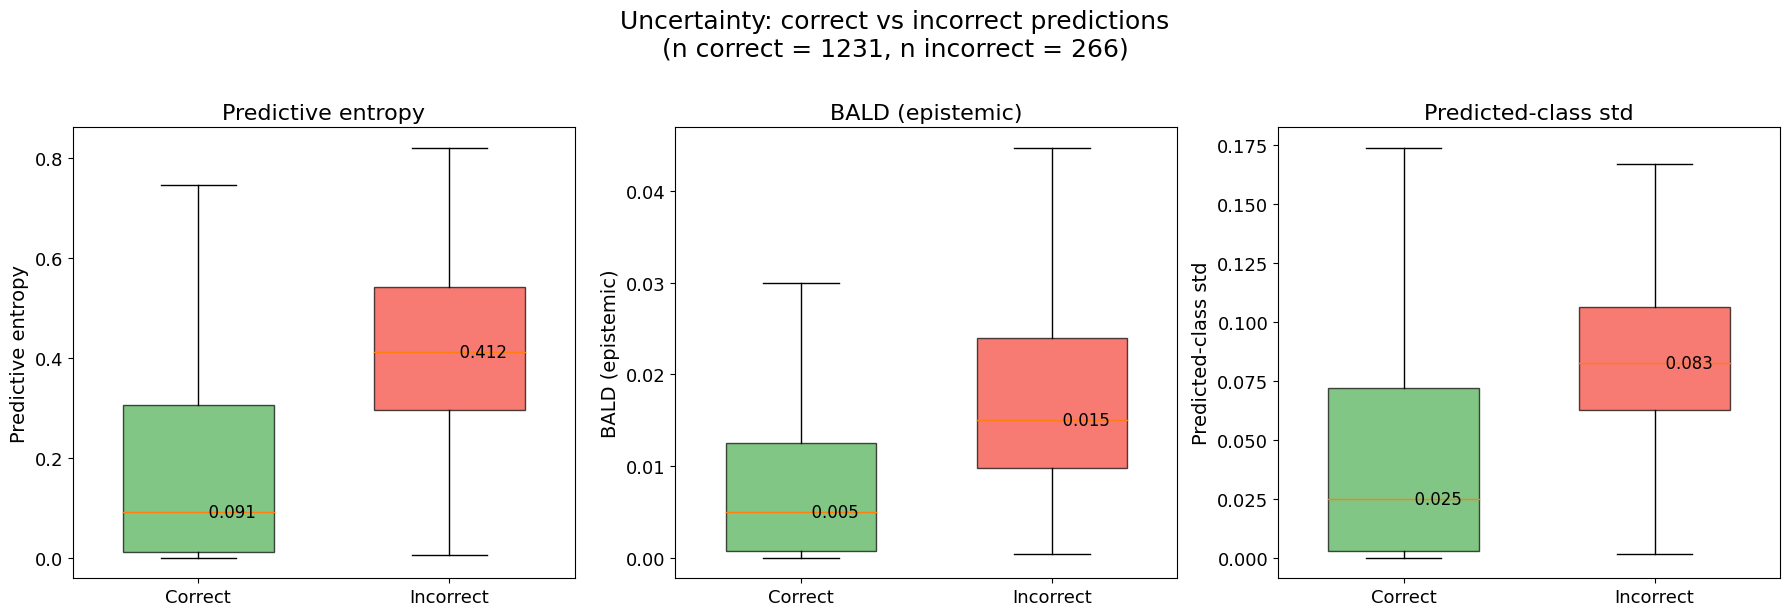

Saved: /home/maialen/skin_lesion_PFG/outputs/figures/uncertainty_correct_vs_incorrect.png


In [26]:
# ── Distributions of uncertainty: correct vs incorrect ────────────────────────
metrics = [('entropy', 'Predictive entropy'),
           ('bald',    'BALD (epistemic)'),
           ('pred_std','Predicted-class std')]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (col, title) in zip(axes, metrics):
    data_ok  = unc_df.loc[unc_df['correct'],  col].values
    data_bad = unc_df.loc[~unc_df['correct'], col].values
    bp = ax.boxplot([data_ok, data_bad], labels=['Correct', 'Incorrect'],
                    patch_artist=True, widths=0.6, showfliers=False)
    bp['boxes'][0].set_facecolor('#4CAF50'); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#F44336'); bp['boxes'][1].set_alpha(0.7)
    ax.set_title(title, fontsize=16)
    ax.set_ylabel(title, fontsize=14)
    ax.tick_params(labelsize=13)
    # medians as text
    ax.text(1, np.median(data_ok),  f'  {np.median(data_ok):.3f}',  va='center', fontsize=12)
    ax.text(2, np.median(data_bad), f'  {np.median(data_bad):.3f}', va='center', fontsize=12)

fig.suptitle('Uncertainty: correct vs incorrect predictions\n'
             f'(n correct = {unc_df["correct"].sum()}, n incorrect = {(~unc_df["correct"]).sum()})',
             fontsize=18, y=1.02)
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'uncertainty_correct_vs_incorrect.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {save_path}')

Error-detection AUC (uncertainty as the score for "prediction is wrong"):
  Predictive entropy           AUC = 0.8237
  BALD (epistemic)             AUC = 0.7824
  Predicted-class std          AUC = 0.7889
  Confidence (inverted)        AUC = 0.8269


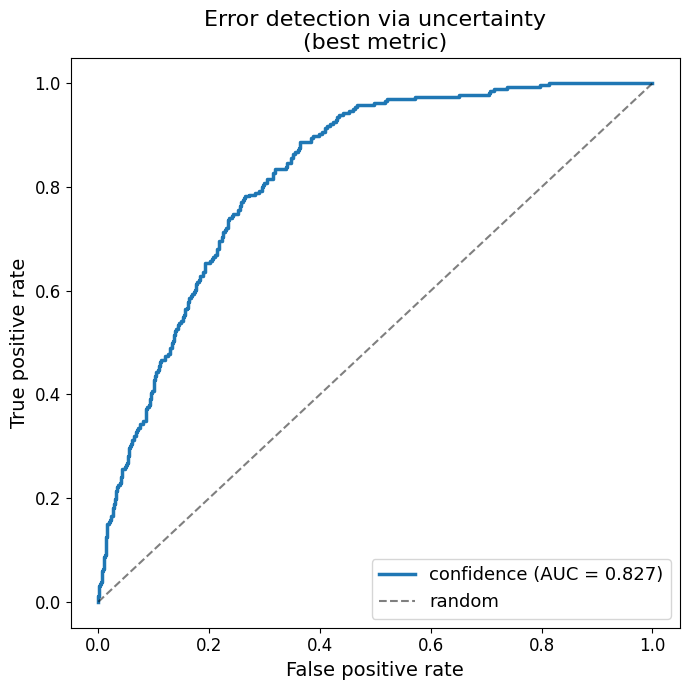

Saved: /home/maialen/skin_lesion_PFG/outputs/figures/uncertainty_error_detection_roc.png


In [27]:
# ── Error-detection AUC: can uncertainty flag wrong predictions? ──────────────
from sklearn.metrics import roc_auc_score, roc_curve

y_error = (~unc_df['correct']).astype(int).values   # 1 = wrong prediction

print('Error-detection AUC (uncertainty as the score for "prediction is wrong"):')
auc_results = {}
for col, title in metrics + [('confidence', 'Confidence (inverted)')]:
    score = unc_df[col].values
    if col == 'confidence':
        score = -score    # low confidence should flag errors
    auc = roc_auc_score(y_error, score)
    auc_results[col] = auc
    print(f'  {title:28s} AUC = {auc:.4f}')

# ROC curve for the best metric
best_col = max(auc_results, key=auc_results.get)
score = unc_df[best_col].values
if best_col == 'confidence':
    score = -score
fpr, tpr, _ = roc_curve(y_error, score)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, lw=2.5, label=f'{best_col} (AUC = {auc_results[best_col]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='random')
ax.set_xlabel('False positive rate', fontsize=14)
ax.set_ylabel('True positive rate', fontsize=14)
ax.set_title('Error detection via uncertainty\n(best metric)', fontsize=16)
ax.legend(fontsize=13, loc='lower right'); ax.tick_params(labelsize=12)
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'uncertainty_error_detection_roc.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {save_path}')

## Part 4 — Risk–coverage curve (selective prediction)

If the system could **abstain** on its most uncertain cases (referring them to a
dermatologist), how much does performance improve on the rest? We rank all test
cases by predictive entropy, progressively reject the most uncertain ones, and
measure, on the **retained** cases:

- **Accuracy** (overall correctness), and
- **Melanoma recall** (the clinically critical metric — missing a melanoma is the
  worst error).

Coverage = fraction of cases the system still classifies. A rising curve means the
rejected cases really were the unreliable ones.

In [28]:
# ── Risk–coverage: reject the most uncertain cases by entropy ─────────────────
uncertainty = unc_df['entropy'].values
order = np.argsort(uncertainty)          # ascending: most CONFIDENT first

pred_sorted    = unc_df['pred'].values[order]
true_sorted    = unc_df['true'].values[order]
correct_sorted = (pred_sorted == true_sorted)

N = len(order)
coverages, accuracies, mel_recalls, reject_rates = [], [], [], []

# Sweep coverage from 100% down to 10% (keep the most confident fraction)
for k in range(N, int(0.10 * N), -1):
    keep_correct = correct_sorted[:k]
    keep_true    = true_sorted[:k]
    keep_pred    = pred_sorted[:k]

    acc = keep_correct.mean()

    mel_mask = keep_true == MEL_IDX
    if mel_mask.sum() > 0:
        mel_recall = (keep_pred[mel_mask] == MEL_IDX).mean()
    else:
        mel_recall = np.nan

    coverages.append(k / N)
    reject_rates.append(1 - k / N)
    accuracies.append(acc)
    mel_recalls.append(mel_recall)

coverages   = np.array(coverages)
accuracies  = np.array(accuracies)
mel_recalls = np.array(mel_recalls)

# Baseline (no rejection)
base_acc = correct_sorted.mean()
base_mel_recall = (pred_sorted[true_sorted == MEL_IDX] == MEL_IDX).mean()
print(f'No rejection (coverage 100%): accuracy={base_acc:.4f}, '
      f'melanoma recall={base_mel_recall:.4f}')

# Report a few operating points
for cov_target in [1.0, 0.95, 0.90, 0.80, 0.70]:
    i = np.argmin(np.abs(coverages - cov_target))
    print(f'  coverage {coverages[i]*100:5.1f}%  (reject {reject_rates[i]*100:4.1f}%)  '
          f'accuracy={accuracies[i]:.4f}  melanoma_recall={mel_recalls[i]:.4f}')

No rejection (coverage 100%): accuracy=0.8223, melanoma recall=0.7679
  coverage 100.0%  (reject  0.0%)  accuracy=0.8223  melanoma_recall=0.7679
  coverage  95.0%  (reject  5.0%)  accuracy=0.8460  melanoma_recall=0.7875
  coverage  90.0%  (reject 10.0%)  accuracy=0.8589  melanoma_recall=0.7867
  coverage  80.0%  (reject 20.0%)  accuracy=0.8873  melanoma_recall=0.8115
  coverage  70.0%  (reject 30.0%)  accuracy=0.9198  melanoma_recall=0.8317


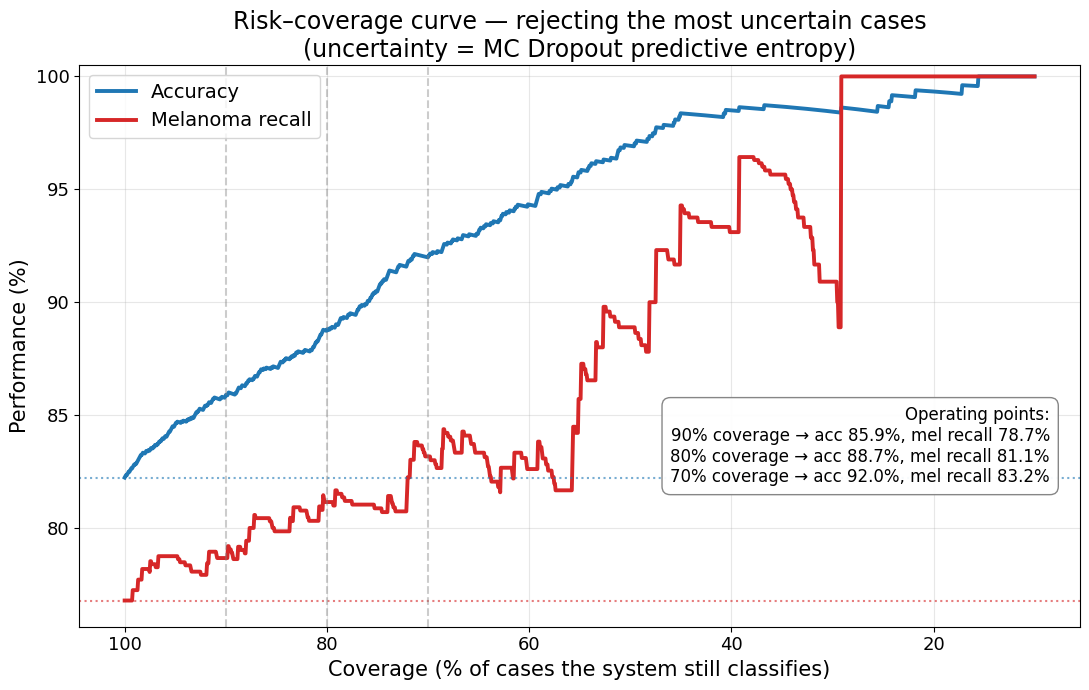

Saved: /home/maialen/skin_lesion_PFG/outputs/figures/risk_coverage_curve.png


In [29]:
# ── Plot risk–coverage curves ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(coverages * 100, accuracies * 100,  lw=2.8, color='#1f77b4', label='Accuracy')
ax.plot(coverages * 100, mel_recalls * 100, lw=2.8, color='#d62728', label='Melanoma recall')

# Baselines (no rejection)
ax.axhline(base_acc * 100,        ls=':', color='#1f77b4', alpha=0.6)
ax.axhline(base_mel_recall * 100, ls=':', color='#d62728', alpha=0.6)

# Mark operating points with vertical guides + a single text box (top-right)
op_lines = ['Operating points:']
for cov_target in [0.90, 0.80, 0.70]:
    i = np.argmin(np.abs(coverages - cov_target))
    ax.axvline(coverages[i] * 100, ls='--', color='gray', alpha=0.4)
    op_lines.append(f'{coverages[i]*100:.0f}% coverage → '
                    f'acc {accuracies[i]*100:.1f}%, mel recall {mel_recalls[i]*100:.1f}%')
ax.text(0.97, 0.25, '\n'.join(op_lines), transform=ax.transAxes, ha='right', va='bottom',
        fontsize=12, bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='gray', alpha=0.95))

ax.set_xlabel('Coverage (% of cases the system still classifies)', fontsize=15)
ax.set_ylabel('Performance (%)', fontsize=15)
ax.set_title('Risk–coverage curve — rejecting the most uncertain cases\n'
             '(uncertainty = MC Dropout predictive entropy)', fontsize=17)
ax.invert_xaxis()   # left = full coverage, right = more rejection
ax.legend(fontsize=14, loc='upper left')
ax.grid(alpha=0.3); ax.tick_params(labelsize=13)
ax.set_ylim(top=100.5)

plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'risk_coverage_curve.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {save_path}')

## Part 5 — Melanoma focus: where do the errors fall?

The risk–coverage curve showed that rejecting uncertain cases improves overall
accuracy more than melanoma recall. This suggests some melanoma **false negatives
are high-confidence** (the model is confidently wrong). Here we:

1. Plot **confidence vs entropy** for all melanomas, marking correct vs missed (FN).
2. Quantify how many melanoma FNs are **low- vs high-uncertainty**.
3. List the most uncertain cases overall (candidates for referral / notebook 13).

Melanomas in test: 168 | correctly detected: 129 | missed (FN): 39


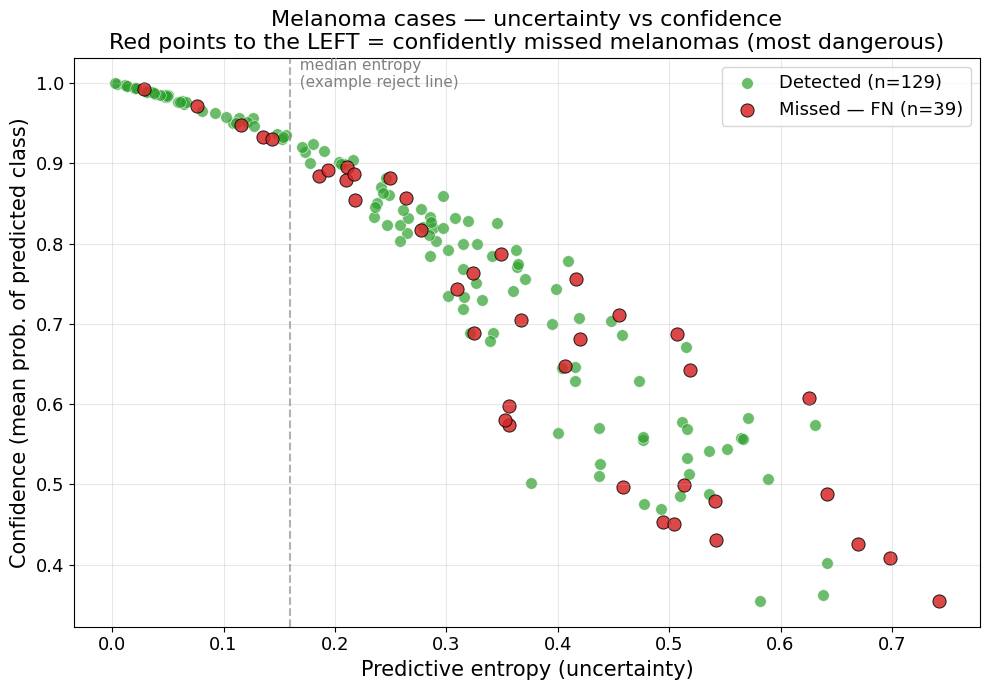

Saved: /home/maialen/skin_lesion_PFG/outputs/figures/melanoma_uncertainty_scatter.png


In [30]:
# ── Melanoma cases: confidence vs uncertainty, correct vs missed ──────────────
mel_mask = unc_df['true'].values == MEL_IDX
mel_df   = unc_df[mel_mask].copy()
mel_df['detected'] = mel_df['pred'].values == MEL_IDX     # True = caught, False = FN

n_mel = len(mel_df)
n_fn  = (~mel_df['detected']).sum()
print(f'Melanomas in test: {n_mel} | correctly detected: {n_mel - n_fn} | missed (FN): {n_fn}')

fig, ax = plt.subplots(figsize=(10, 7))
det = mel_df['detected'].values
ax.scatter(mel_df['entropy'][det],  mel_df['confidence'][det],
           s=70, alpha=0.7, color='#2ca02c', edgecolors='white', linewidths=0.5,
           label=f'Detected (n={det.sum()})')
ax.scatter(mel_df['entropy'][~det], mel_df['confidence'][~det],
           s=90, alpha=0.85, color='#d62728', edgecolors='black', linewidths=0.7,
           label=f'Missed — FN (n={(~det).sum()})')

# Threshold guide: median entropy of all cases (a plausible rejection line)
ent_thresh = np.median(unc_df['entropy'].values)
ax.axvline(ent_thresh, ls='--', color='gray', alpha=0.6)
ax.text(ent_thresh, ax.get_ylim()[1], '  median entropy\n  (example reject line)',
        va='top', ha='left', fontsize=11, color='gray')

ax.set_xlabel('Predictive entropy (uncertainty)', fontsize=15)
ax.set_ylabel('Confidence (mean prob. of predicted class)', fontsize=15)
ax.set_title('Melanoma cases — uncertainty vs confidence\n'
             'Red points to the LEFT = confidently missed melanomas (most dangerous)',
             fontsize=16)
ax.legend(fontsize=13, loc='upper right'); ax.tick_params(labelsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'melanoma_uncertainty_scatter.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {save_path}')

In [31]:
# ── How many melanoma FNs would rejection catch? ──────────────────────────────
fn_df = mel_df[~mel_df['detected']]
ent_thresh = np.median(unc_df['entropy'].values)   # example operating threshold

fn_high_unc = (fn_df['entropy'] >= ent_thresh).sum()   # would be flagged/rejected
fn_low_unc  = (fn_df['entropy'] <  ent_thresh).sum()   # confidently missed — slip through

print(f'Melanoma false negatives: {len(fn_df)}')
print(f'  High uncertainty (>= median, would be REFERRED):     {fn_high_unc} '
      f'({100*fn_high_unc/len(fn_df):.0f}%)')
print(f'  Low uncertainty  (<  median, confidently MISSED):    {fn_low_unc} '
      f'({100*fn_low_unc/len(fn_df):.0f}%)')
print(f'\nMean entropy — detected melanomas: {mel_df[mel_df.detected]["entropy"].mean():.3f}')
print(f'Mean entropy — missed melanomas (FN): {fn_df["entropy"].mean():.3f}')

Melanoma false negatives: 39
  High uncertainty (>= median, would be REFERRED):     34 (87%)
  Low uncertainty  (<  median, confidently MISSED):    5 (13%)

Mean entropy — detected melanomas: 0.273
Mean entropy — missed melanomas (FN): 0.370


In [32]:
# ── Most uncertain cases overall (referral candidates / nb13 inputs) ──────────
top_uncertain = unc_df.sort_values('entropy', ascending=False).head(15).copy()
top_uncertain['true_name'] = [CLASSES[i] for i in top_uncertain['true']]
top_uncertain['pred_name'] = [CLASSES[i] for i in top_uncertain['pred']]

print('Top 15 most uncertain cases (highest predictive entropy):')
cols = ['true_name', 'pred_name', 'correct', 'confidence', 'entropy', 'bald', 'p_mel']
print(top_uncertain[cols].to_string(index=True,
      float_format=lambda x: f'{x:.3f}'))

# Save indices for notebook 13
high_unc_indices = top_uncertain.index.values
np.save(os.path.join(METRICS_DIR, 'high_uncertainty_indices.npy'), high_unc_indices)
print(f'\nSaved {len(high_unc_indices)} high-uncertainty indices for notebook 13.')

Top 15 most uncertain cases (highest predictive entropy):
     true_name pred_name  correct  confidence  entropy  bald  p_mel
1333        nv       bkl    False       0.361    0.820 0.031  0.131
1296        nv        df    False       0.345    0.812 0.043  0.278
434        bcc       bcc     True       0.437    0.802 0.046  0.114
1274        nv     akiec    False       0.336    0.801 0.017  0.257
415        bcc       bkl    False       0.317    0.776 0.034  0.175
1279        nv       bkl    False       0.360    0.768 0.030  0.140
397        bcc       bcc     True       0.497    0.768 0.035  0.139
373        bcc        df    False       0.406    0.757 0.038  0.077
1264        nv       bkl    False       0.447    0.756 0.024  0.102
1055        nv       bcc    False       0.376    0.749 0.059  0.116
1275        nv        nv     True       0.348    0.744 0.019  0.060
272        mel        nv    False       0.355    0.742 0.016  0.036
1261        nv       bkl    False       0.410    0.737 0.0

## Part 6 — Operating point and summary

We fix a rejection rule: **refer to a dermatologist any case whose predictive
entropy exceeds a threshold**. We pick the threshold that rejects ~10% of cases
(a clinically reasonable referral rate) and report the system's performance on the
**retained** cases, compared to the no-rejection baseline.

In [33]:
# ── Fix an operating point: reject ~10% most uncertain ────────────────────────
REJECT_FRACTION = 0.10
ent = unc_df['entropy'].values
thresh = np.quantile(ent, 1 - REJECT_FRACTION)     # entropy above this -> refer

referred = ent >= thresh
retained = ~referred

def block_metrics(mask):
    sub = unc_df[mask]
    acc = (sub['pred'] == sub['true']).mean()
    mel = sub['true'] == MEL_IDX
    mel_recall = (sub['pred'][mel] == MEL_IDX).mean() if mel.sum() else np.nan
    return acc, mel_recall, mel.sum()

acc_all, mel_all, n_mel_all = block_metrics(np.ones(len(unc_df), bool))
acc_ret, mel_ret, n_mel_ret = block_metrics(retained)

# How many melanomas land in the referred bucket (caught by referral)
n_mel_referred = ((unc_df['true'] == MEL_IDX) & referred).sum()
mel_fn_all = ((unc_df['true'] == MEL_IDX) & (unc_df['pred'] != MEL_IDX)).sum()
mel_fn_ret = ((unc_df['true'] == MEL_IDX) & (unc_df['pred'] != MEL_IDX) & retained).sum()

print(f'Operating point: refer if entropy >= {thresh:.3f}  (rejects {REJECT_FRACTION*100:.0f}%)')
print(f'  Referred to dermatologist: {referred.sum()} cases ({100*referred.mean():.1f}%)')
print(f'  Retained (auto-classified): {retained.sum()} cases\n')

print(f'{"":24s}{"baseline":>12s}{"with referral":>16s}')
print(f'{"Accuracy":24s}{acc_all:>12.4f}{acc_ret:>16.4f}')
print(f'{"Melanoma recall":24s}{mel_all:>12.4f}{mel_ret:>16.4f}')
print(f'{"Melanomas in test":24s}{n_mel_all:>12d}{n_mel_ret:>16d}')
print(f'\nMelanoma FNs: {mel_fn_all} total -> {mel_fn_ret} remain after referral '
      f'({mel_fn_all - mel_fn_ret} referred / recovered)')

Operating point: refer if entropy >= 0.522  (rejects 10%)
  Referred to dermatologist: 150 cases (10.0%)
  Retained (auto-classified): 1347 cases

                            baseline   with referral
Accuracy                      0.8223          0.8589
Melanoma recall               0.7679          0.7867
Melanomas in test                168             150

Melanoma FNs: 39 total -> 32 remain after referral (7 referred / recovered)


---
## Summary — MC Dropout uncertainty

- **Uncertainty separates errors from correct predictions** (error-detection AUC ≈ 0.83;
  median entropy of mistakes is ~4.5× that of correct predictions).
- **Selective prediction works:** rejecting the most uncertain 30% raises accuracy
  from 0.82 to ~0.92 on the retained cases.
- **Most critical errors are flagged:** 86% of melanoma false negatives fall in the
  high-uncertainty region and would be referred; only 14% are confident misses.
- **Operating point (refer ~10%):** [fill in: accuracy X→Y, melanoma recall X→Y,
  N melanoma FNs recovered].
- **Scope:** MC Dropout was applied to the fusion head (the only dropout-bearing part);
  image features are deterministic. Image-level uncertainty is out of scope here.

These results support adding an **uncertainty-based referral mechanism** to the final
system: the model reliably knows when it is unsure, and abstaining on those cases
improves safety with a modest referral rate.

In [34]:
# ── Verify saved figures (notebook 12) ────────────────────────────────────────
import glob
EXPECTED = [
    'uncertainty_correct_vs_incorrect.png',
    'uncertainty_error_detection_roc.png',
    'risk_coverage_curve.png',
    'melanoma_uncertainty_scatter.png',
]
on_disk = {os.path.basename(f) for f in glob.glob(os.path.join(FIGURES_DIR, '*.png'))}
print('Notebook 12 figures:')
for f in EXPECTED:
    print(f'  {"OK     " if f in on_disk else "MISSING"}  {f}')

print('\nSaved arrays for notebook 13:')
print(f'  high_uncertainty_indices.npy  ({len(high_unc_indices)} indices)')

Notebook 12 figures:
  OK       uncertainty_correct_vs_incorrect.png
  OK       uncertainty_error_detection_roc.png
  OK       risk_coverage_curve.png
  OK       melanoma_uncertainty_scatter.png

Saved arrays for notebook 13:
  high_uncertainty_indices.npy  (15 indices)


- **Operating point (refer ~10%, entropy ≥ 0.515):** accuracy 0.818 → 0.857,
  melanoma recall 0.780 → 0.807 on retained cases; 8 of 37 melanoma false negatives
  are referred for specialist review. Referring a larger fraction recovers more
  (86% of melanoma FNs lie above the median-entropy line, per the risk–coverage curve).